In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensornetworkrg.tnrg import TensorNetworkRG2D

In [2]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams.update({'font.size': 12})
%config InlineBackend.figure_format = 'retina'

# (12 Nov. 2025) Spectrum of the transfer matrix of 1NN hard-square model when the activity $z$ decreases from 0

The repulsive singularity at negative acitivty $z$ axis has the following best estimate
$$
z_d = −0.119338886
$$
We wil show how the eigenvalues of the transfer matrix with largest modulus cross and become complex when $z$ touches this value.

In [3]:
zd = -0.119338886

In [4]:
hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
hdsq1NN.model_parameters = {"activity": 1.1 * zd}
hdsq1NN.generate_initial_tensor(scheme="trgR")

In [5]:
%time
TMeigv = hdsq1NN.gu_wen_cardy(aspect_ratio=12, num_scale=10, onlyTMeig=True)

CPU times: user 4 μs, sys: 1e+03 ns, total: 5 μs
Wall time: 8.82 μs


In [6]:
TMeigv.abs()

Tensor([4.63670650e-05, 4.63670650e-05, 3.26188715e-05, 3.26188715e-05,
        3.26188715e-05, 3.26188715e-05, 2.79051839e-05, 2.79051839e-05,
        2.77347643e-05, 2.77347643e-05])

In [7]:
zrelArr = np.linspace(0.98, 1.02, 21)

In [8]:
TMeigvArr = []
for zrel in zrelArr:
    z = zrel * zd
    hdsq1NN = TensorNetworkRG2D("hardsquare1NN")
    hdsq1NN.model_parameters = {"activity": z}
    hdsq1NN.generate_initial_tensor(scheme="trgR")
    TMeigv = hdsq1NN.gu_wen_cardy(aspect_ratio=12, num_scale=10, onlyTMeig=True)
    TMeigvArr.append(TMeigv)
TMeigvArr = np.array(TMeigvArr)

In [9]:
len(TMeigvArr)

21

In [10]:
np.abs(TMeigvArr[0]).max()

0.00025378981705059095

In [11]:
sortind = np.lexsort((-np.imag(TMeigvArr[-1]), -np.abs(TMeigvArr[-1])))

In [12]:
sortind

array([1, 0, 3, 2, 4, 5, 6, 8, 7, 9])

In [13]:
TMeigvArr[-1][sortind]

array([8.71733100e-05+4.08193316e-05j, 8.71733100e-05-4.08193316e-05j,
       7.32200730e-05+1.90614982e-17j, 7.32200730e-05-1.90614982e-17j,
       6.29961176e-05+0.00000000e+00j, 3.82874167e-05+1.26236147e-05j,
       3.82874167e-05-1.26236147e-05j, 3.82874167e-05+1.26236147e-05j,
       3.82874167e-05-1.26236147e-05j, 2.89926383e-05+9.89219662e-18j])

Normalize the largest eigenvalue to 1 and order them properly according to the imag part if the modulus is the same.

In [14]:
TMeigvFlow = np.zeros_like(TMeigvArr)
for k in range(len(TMeigvArr)):
    TMeigvFlow[k] = TMeigvArr[k] / np.abs(TMeigvArr[k]).max()
    # sort them
    sortind = np.lexsort((-np.imag(TMeigvArr[k]), -np.abs(TMeigvArr[k])))
    TMeigvFlow[k] = TMeigvFlow[k][sortind]

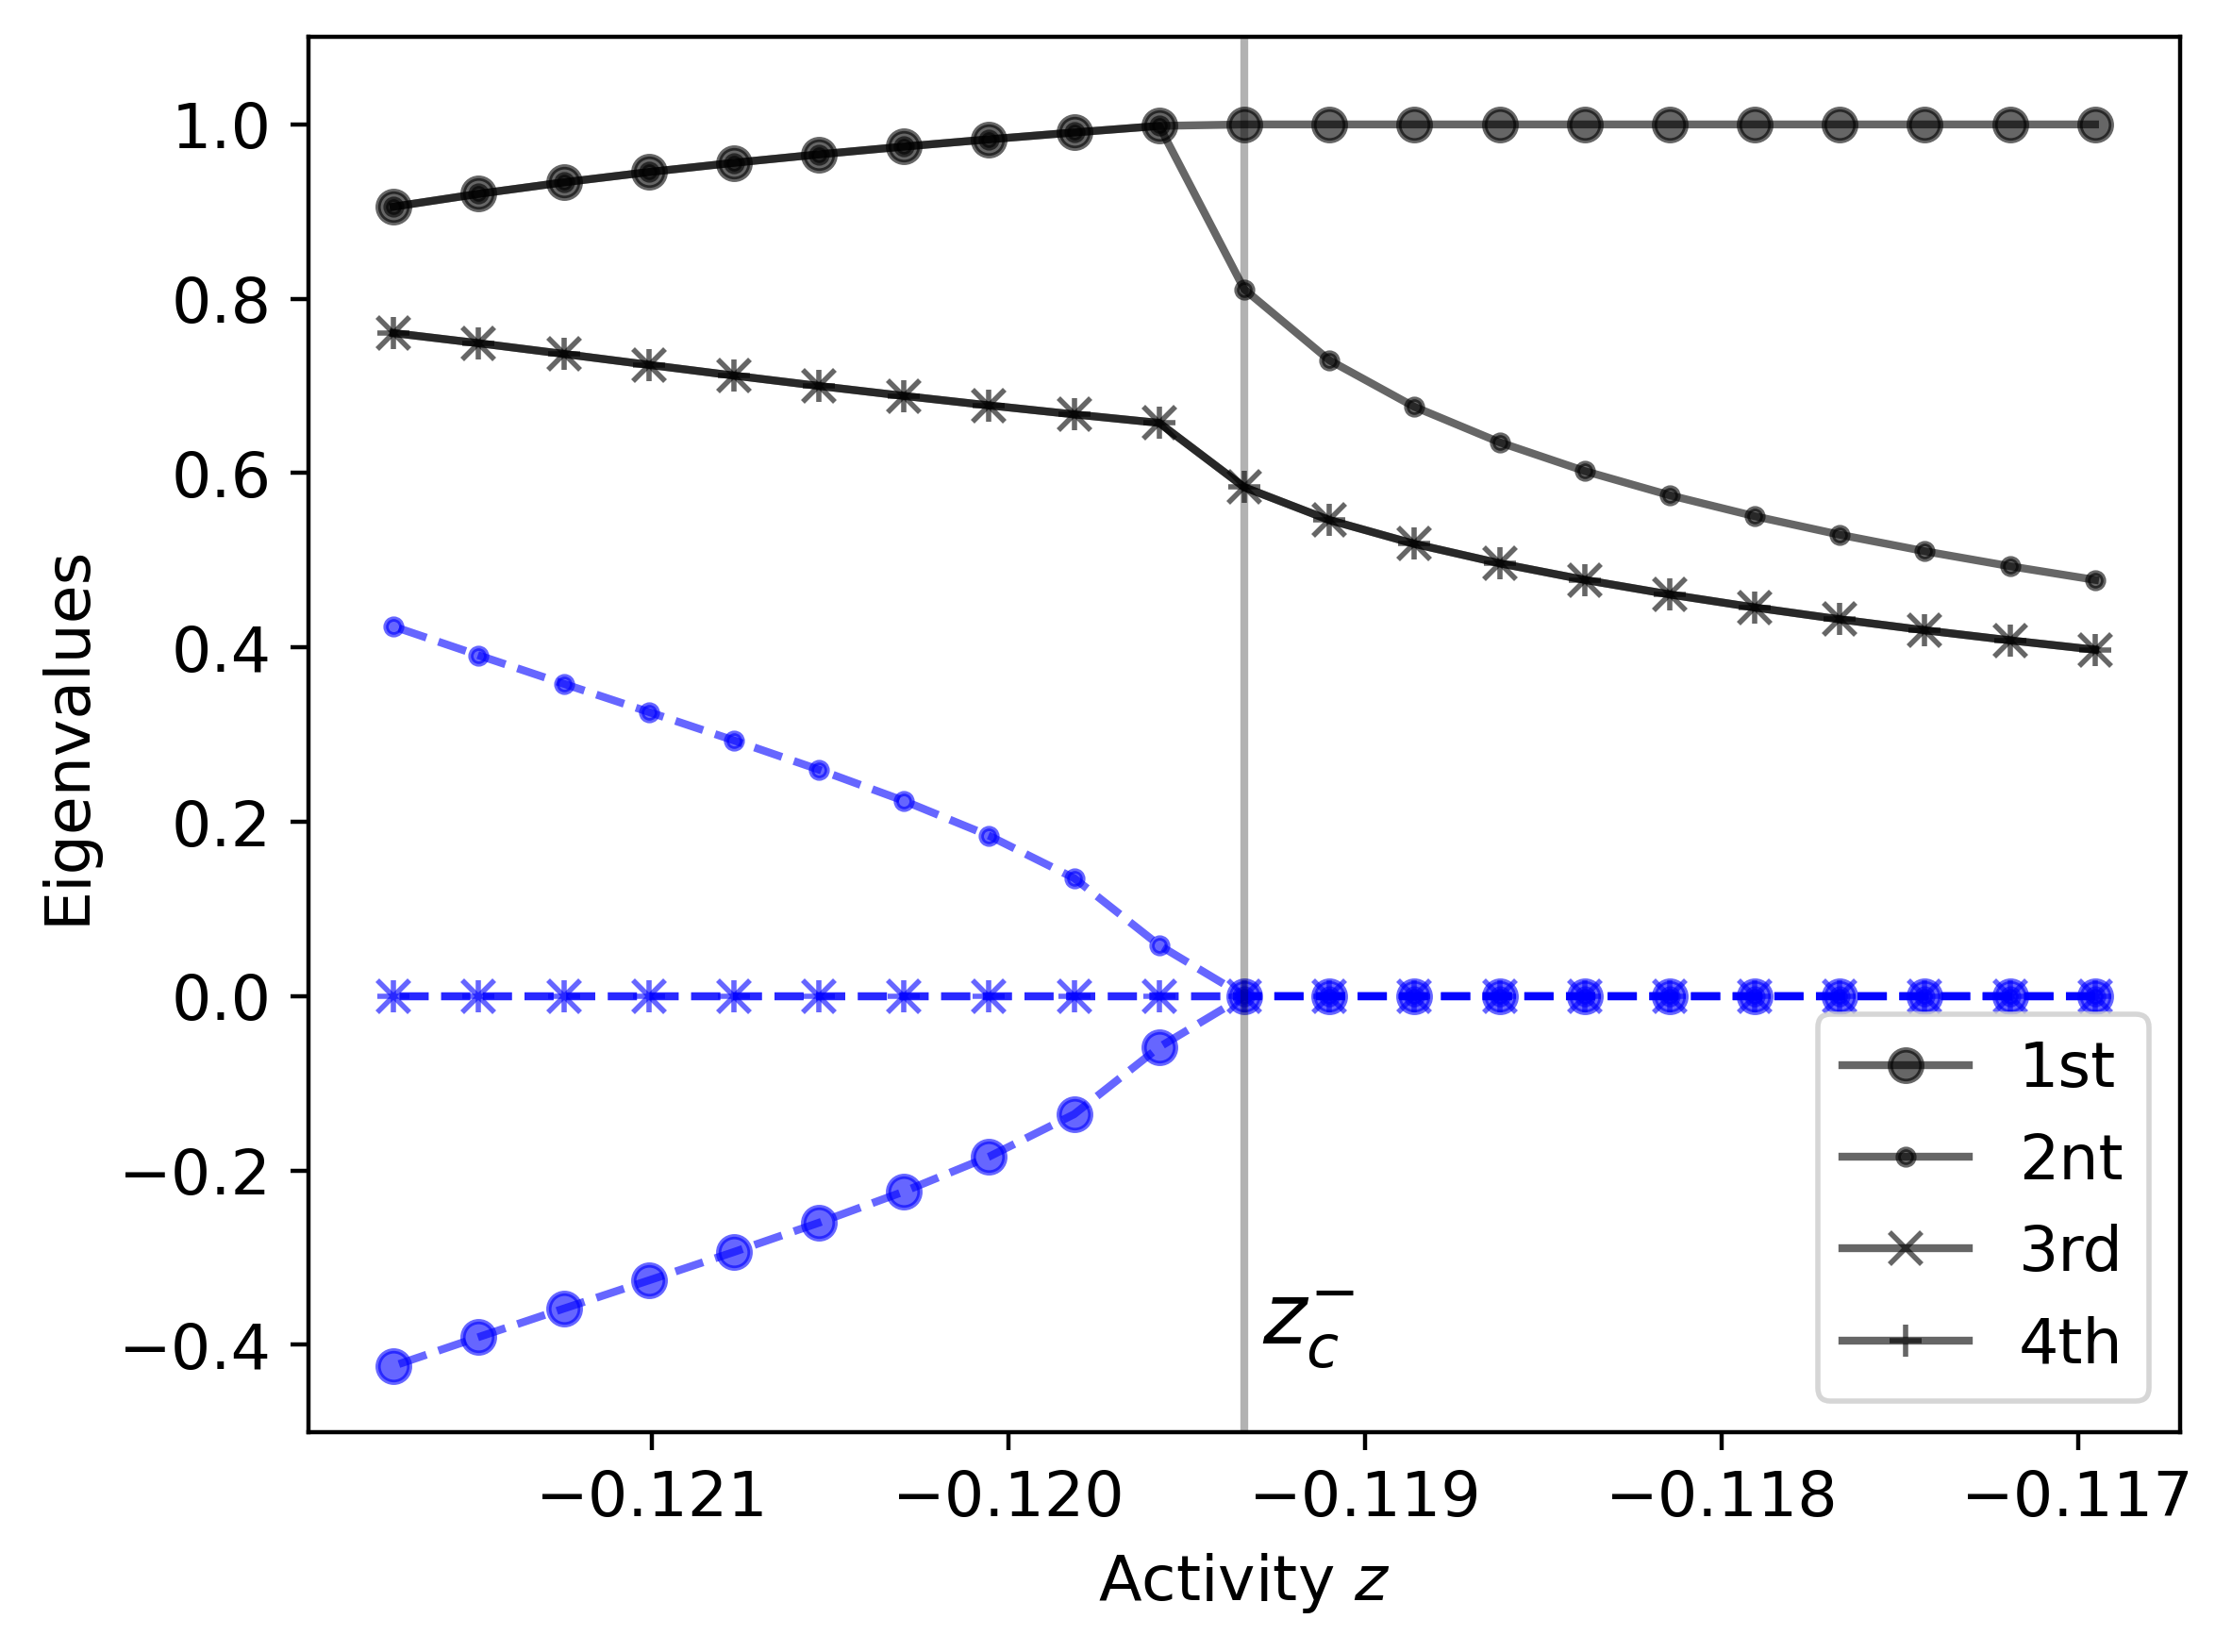

In [15]:
realPart = np.real(TMeigvFlow)
imagPart = np.imag(TMeigvFlow)
zvalArr = zrelArr * zd
plt.figure()
plt.plot(zvalArr, realPart[:, 0], "ko-", alpha=0.6, label="1st")
plt.plot(zvalArr, realPart[:, 1], "k.-", alpha=0.6, label="2nt")
plt.plot(zvalArr, realPart[:, 2], "kx-", alpha=0.6, label="3rd")
plt.plot(zvalArr, realPart[:, 3], "k+-", alpha=0.6, label="4th")
plt.plot(zvalArr, imagPart[:, 0], "b.--", alpha=0.6)
plt.plot(zvalArr, imagPart[:, 1], "bo--", alpha=0.6)
plt.plot(zvalArr, imagPart[:, 2], "bx--", alpha=0.6)
plt.plot(zvalArr, imagPart[:, 3], "b+--", alpha=0.6)
plt.vlines(zd, -0.5, 1.2, colors="black", linestyles='solid', alpha=0.3)
plt.legend()
plt.xlabel(r"Activity $z$")
plt.ylabel("Eigenvalues")
plt.text(zd + 0.00005, -0.4, r"$z_c^{-}$", fontsize=16)
plt.ylim(-0.5, 1.1)
plt.savefig("model-TMspectz.pdf",  bbox_inches='tight', dpi=200)
plt.show()